## Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## **Data Preprocessing**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products


In [ ]:
import os

# List all files in the directory
for file in os.listdir(path):
    print(file)

Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


In [ ]:
# Load datasets
df1 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
df2 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))

In [ ]:
# Datasets Shape Check
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

df1 shape: (5000, 24)
df2 shape: (28332, 24)


In [ ]:
# Check columns of each dataset
print("Columns in df1:", df1.columns)
print("Columns in df2:", df2.columns)

Columns in df1: Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')
Columns in df2: Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')


In [ ]:
# Merge datasets df1 and df2
df = pd.concat([df1, df2], ignore_index=True)

In [ ]:
# Missing Value Check
df.isnull().sum()

,0
id,0
dateAdded,0
dateUpdated,0
name,0
asins,0
brand,0
categories,0
primaryCategories,0
imageURLs,0
keys,0


In [ ]:
df.columns

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs',
       'reviews.didPurchase'],
      dtype='object')

In [ ]:
# Select relevant columns
df = df[['name','categories', 'primaryCategories']]

In [ ]:
df.head()

,name,categories,primaryCategories
0,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...","Computers,Electronics Features,Tablets,Electro...",Electronics
1,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...","Computers,Electronics Features,Tablets,Electro...",Electronics
2,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...","Computers,Electronics Features,Tablets,Electro...",Electronics
3,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...","Computers,Electronics Features,Tablets,Electro...",Electronics
4,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...","Computers,Electronics Features,Tablets,Electro...",Electronics


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33332 entries, 0 to 33331
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               33332 non-null  object
 1   categories         33332 non-null  object
 2   primaryCategories  33332 non-null  object
dtypes: object(3)
memory usage: 781.3+ KB


In [ ]:
df.isnull().sum()

,0
name,0
categories,0
primaryCategories,0


In [ ]:
# Identify duplicate rows in the dataset
duplicates = df[df.duplicated()]
print(duplicates.head())
print(len(duplicates))

                                                name  \
1  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
2  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
3  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
4  Amazon Kindle E-Reader 6" Wifi (8th Generation...   
5  Amazon Kindle E-Reader 6" Wifi (8th Generation...   

                                          categories primaryCategories  
1  Computers,Electronics Features,Tablets,Electro...       Electronics  
2  Computers,Electronics Features,Tablets,Electro...       Electronics  
3  Computers,Electronics Features,Tablets,Electro...       Electronics  
4  Computers,Electronics Features,Tablets,Electro...       Electronics  
5  Computers,Electronics Features,Tablets,Electro...       Electronics  
33251


In [ ]:
# Remove duplicate rows from the dataset
df = df.drop_duplicates()

In [ ]:
df.shape

(81, 3)

In [ ]:
df['primaryCategories'].value_counts().head(20)

,count
primaryCategories,
Electronics,59
"Electronics,Media",6
Animals & Pet Supplies,4
"Electronics,Hardware",3
Health & Beauty,2
"Office Supplies,Electronics",2
Home & Garden,2
Office Supplies,1
"Electronics,Furniture",1


In [ ]:
# Extract first/main category from 'categories' or 'primaryCategories'
df.loc[:,'main_category'] = df['categories'].str.split(',').str[0].str.strip()
df.loc[:,'main_category'] = df['main_category'].fillna(df['primaryCategories'])

<ipython-input-21-c054573548dc>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'main_category'] = df['categories'].str.split(',').str[0].str.strip()


In [ ]:
df['main_category'].value_counts()

,count
main_category,
Fire Tablets,19
Amazon Echo,9
eBook Readers,6
Computers,4
Computers & Accessories,4
Amazon SMP,3
Tablets,3
Office,2
AA,2


In [ ]:
top_categories = df['main_category'].value_counts().index.tolist()
top_categories

['Fire Tablets',
 'Amazon Echo',
 'eBook Readers',
 'Computers',
 'Computers & Accessories',
 'Amazon SMP',
 'Tablets',
 'Office',
 'AA',
 'Electronics',
 'Audio & Video Accessories',
 'Home & Garden',
 'Electronics Features',
 'Portable Computer Accessories',
 'Crate Training',
 'E-Readers & Accessories',
 'Consumer Electronics',
 'Computers/Tablets & Networking',
 'Kindle E-readers',
 'Computers & Tablets',
 'Bags',
 'Stereos',
 'Chargers & Adapters',
 'Standard Litter Boxes',
 'Laptop Computer Stands',
 'Accessories',
 'Tablet & eBook Reader Accs',
 'Carriers & Totes',
 'Featured Brands',
 'EBook Readers']

In [ ]:
len(top_categories)

30

In [ ]:
# Define mapping for broader meta-categories
meta_category_mapping = {
    'Fire Tablets': 'Ebook readers',
    'eBook Readers': 'Ebook readers',
    'EBook Readers': 'Ebook readers',
    'Kindle E-readers': 'Ebook readers',
    'Tablet & eBook Reader Accs': 'Accessories',
    ''

    'AA': 'Batteries',
    'Chargers & Adapters': 'Electronics',

    'Computers': 'Electronics',
    'Amazon Echo': 'Electronics',
    'Electronics': 'Electronics',
    'Computers/Tablets & Networking': 'Electronics',
    'Office': 'Home & Office',
    'Tablets': 'Electronics',
    'Computers & Accessories': 'Accessories',
    'Portable Computer Accessories': 'Accessories',
    'Computers & Tablets': 'Electronics',
    'Laptop Computer Stands': 'Accessories',
    'Audio & Video Accessories': 'Accessories',

    'Bags': 'Accessories',
    'Amazon SMP': 'Accessories',
    'Electronics Features': 'Electronics',
    'Consumer Electronics': 'Electronics',
    'Accessories': 'Accessories',
    'Featured Brands': 'Accessories',

    'Crate Training': 'Pet Supplies',
    'Standard Litter Boxes': 'Pet Supplies',
    'Home & Garden': 'Home & Office',
    'Carriers & Totes': 'Pet Supplies',
    'Stereos': 'Accessories'
}

# Apply the mapping to a new column
df.loc[:,'meta_category'] = df['main_category'].map(meta_category_mapping)


<ipython-input-25-8e1b025d7c2a>:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'meta_category'] = df['main_category'].map(meta_category_mapping)


In [ ]:
df.isnull().sum()

,0
name,0
categories,0
primaryCategories,0
main_category,0
meta_category,2


In [ ]:
df.loc[:,'meta_category'] = df['main_category'].map(meta_category_mapping).fillna('Other')


##  BERT Embeddings + Clustering for Advanced Category

In [ ]:
from transformers import BertTokenizer, BertModel
import torch
import pandas as pd
from sentence_transformers import SentenceTransformer

category_text = df['meta_category'].tolist()

# Load Sentence-BERT model for embeddings
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Generate embeddings for each product category
embeddings = model.encode(category_text, show_progress_bar=True)

# Convert the embeddings into a DataFrame for further analysis
embeddings_df = pd.DataFrame(embeddings)


print(embeddings_df.head())


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.51k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

        0         1         2         3         4         5         6    \
0 -0.717248  0.585129 -0.112688 -0.497001  0.511647 -0.530318  0.480983   
1 -0.717248  0.585129 -0.112688 -0.497001  0.511647 -0.530318  0.480983   
2 -0.717248  0.585129 -0.112688 -0.497001  0.511647 -0.530318  0.480983   
3 -0.530066  0.195298  0.073224 -0.264345  0.083625  0.222139  1.000017   
4 -0.717248  0.585129 -0.112688 -0.497001  0.511647 -0.530318  0.480983   

        7         8         9    ...       374       375       376       377  \
0  0.165509  0.448598 -0.083938  ...  0.100615 -0.505463  0.134901  0.070966   
1  0.165509  0.448598 -0.083938  ...  0.100615 -0.505463  0.134901  0.070966   
2  0.165509  0.448598 -0.083938  ...  0.100615 -0.505463  0.134901  0.070966   
3 -0.128242 -0.074231 -0.423308  ... -0.520029 -0.314863  0.457425  0.322286   
4  0.165509  0.448598 -0.083938  ...  0.100615 -0.505463  0.134901  0.070966   

        378       379       380       381       382       383  
0 -0

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply KMeans clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(embeddings_df)

# Add the cluster labels to the original dataframe
df['cluster_labels'] = kmeans_labels

# Check the results by looking at the product categories in each cluster
for i in range(n_clusters):
    print(f"Cluster {i}:")
    print(df[df['cluster_labels'] == i]['meta_category'].head(10))


Cluster 0:
5000     Batteries
13358    Batteries
Name: meta_category, dtype: object
Cluster 1:
1565     Ebook readers
1573     Ebook readers
1619     Ebook readers
1633     Ebook readers
3211     Ebook readers
3218     Ebook readers
3341     Ebook readers
4762     Ebook readers
4801     Ebook readers
17871    Ebook readers
Name: meta_category, dtype: object
Cluster 2:
0       Electronics
96      Electronics
746     Electronics
945     Electronics
1557    Electronics
2986    Electronics
3423    Electronics
4220    Electronics
4687    Electronics
4709    Electronics
Name: meta_category, dtype: object
Cluster 3:
941       Accessories
1535      Accessories
13343     Accessories
13347     Accessories
17086     Accessories
17098     Accessories
17123     Accessories
17129     Accessories
17165    Pet Supplies
17167     Accessories
Name: meta_category, dtype: object
Cluster 4:
1560     Home & Office
17156    Home & Office
17211    Home & Office
18376    Home & Office
Name: meta_category, dtyp

<ipython-input-41-38086ac7d32c>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster_labels'] = kmeans_labels


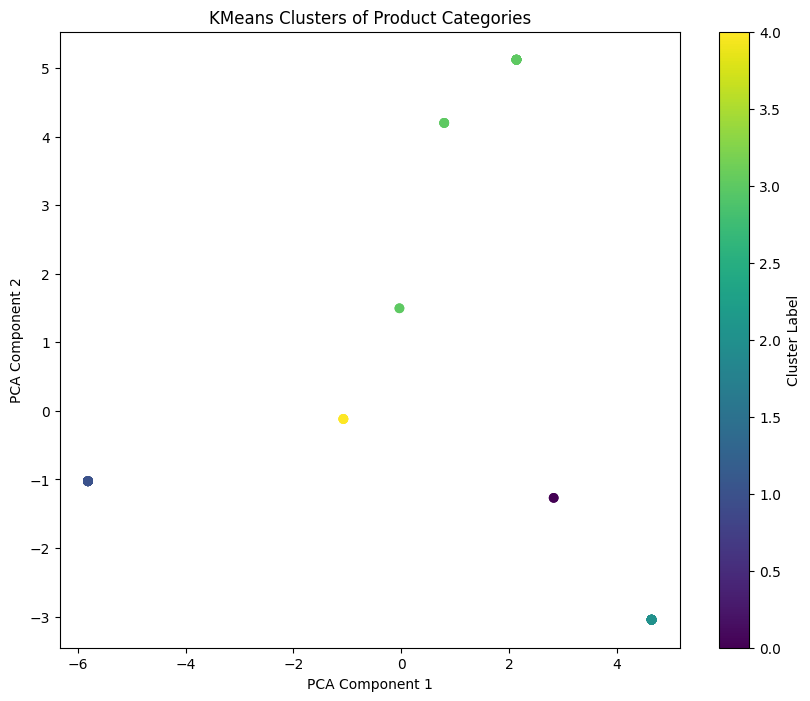

In [ ]:
from sklearn.decomposition import PCA

# Reduce the dimensionality of the embeddings to 2D using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_df)

# Plot the clusters
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans_labels, cmap='viridis')
plt.title('KMeans Clusters of Product Categories')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(embeddings, kmeans_labels)
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.886


In [ ]:
from sklearn.metrics import calinski_harabasz_score

score = calinski_harabasz_score(embeddings, kmeans_labels)
print(f"Calinski-Harabasz Score: {score:.2f}")

Calinski-Harabasz Score: 146.59


In [ ]:
cluster_sizes = df['cluster_labels'].value_counts()
print(cluster_sizes)


cluster_labels
1    27
2    25
3    23
4     4
0     2
Name: count, dtype: int64


In [ ]:
df.columns

Index(['name', 'categories', 'primaryCategories', 'main_category',
       'meta_category', 'cluster_labels'],
      dtype='object')

In [ ]:
cluster_names = {
    0: "Batteries",
    1: "Ebook readers",
    2: "Electronics",
    4: "Home & Office",
    3: "Accessories",
}

df.loc[:,'cluster_name'] = df['cluster_labels'].map(cluster_names)

<ipython-input-42-f12788000593>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'cluster_name'] = df['cluster_labels'].map(cluster_names)


In [ ]:
df

,name,categories,primaryCategories,main_category,meta_category,cluster_labels,cluster_name
0,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...","Computers,Electronics Features,Tablets,Electro...",Electronics,Computers,Electronics,2,Electronics
96,Amazon Echo Show Alexa-enabled Bluetooth Speak...,"Computers,Amazon Echo,Virtual Assistant Speake...","Electronics,Hardware",Computers,Electronics,2,Electronics
746,Amazon Echo Show Alexa-enabled Bluetooth Speak...,"Amazon Echo,Virtual Assistant Speakers,Electro...","Electronics,Hardware",Amazon Echo,Electronics,2,Electronics
941,Amazon Fire TV with 4K Ultra HD and Alexa Voic...,"Amazon SMP,TV, Video & Home Audio,Electronics,...",Electronics,Amazon SMP,Accessories,3,Accessories
945,Amazon - Echo Plus w/ Built-In Hub - Silver,"Amazon Echo,Smart Home,Networking,Home & Tools...","Electronics,Hardware",Amazon Echo,Electronics,2,Electronics
...,...,...,...,...,...,...,...
30864,Certified Refurbished Amazon Fire TV with Alex...,"Amazon SMP,Categories,Streaming Media Players,...",Electronics,Amazon SMP,Accessories,3,Accessories
30871,All-New Kindle Oasis E-reader - 7 High-Resolut...,"E-Readers & Accessories,EBook Readers,Amazon B...","Electronics,Media",E-Readers & Accessories,Other,3,Accessories
30878,AmazonBasics Bluetooth Keyboard for Android De...,"Electronics Features,Computers & Accessories,C...",Electronics,Electronics Features,Electronics,2,Electronics
30884,Amazon Kindle Replacement Power Adapter (Fits ...,"Computers & Accessories,Electronics,Amazon Dev...",Electronics,Computers & Accessories,Accessories,3,Accessories


In [ ]:
df['cluster_labels'].value_counts()

,count
cluster_labels,
1,27
2,25
3,19
4,4
5,4
0,2


In [ ]:
# Analyze the clusters more thoroughly
cluster_analysis = df.groupby('cluster_labels')['meta_category'].value_counts()
print(cluster_analysis)

cluster_labels  meta_category
0               Batteries         2
1               Ebook readers    27
2               Electronics      25
3               Accessories      17
                Pet Supplies      4
                Other             2
4               Home & Office     4
Name: count, dtype: int64


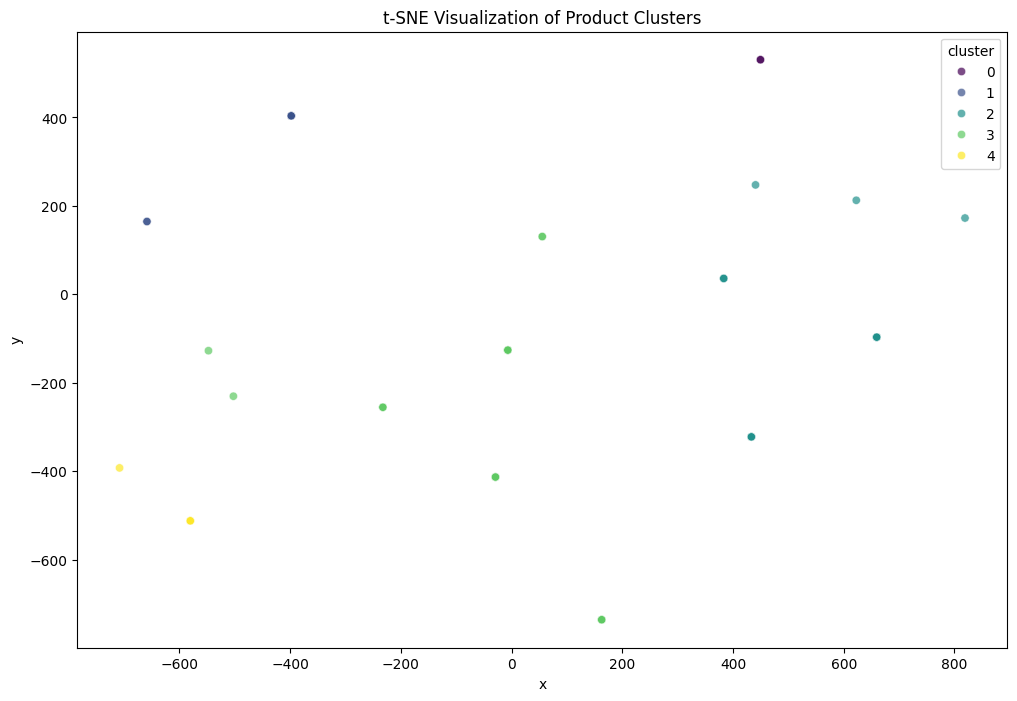

In [ ]:
#  Visualize the clusters using dimensionality reduction
from sklearn.manifold import TSNE
import seaborn as sns

# Reduce dimensions for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced_embeddings = tsne.fit_transform(embeddings_df)

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'x': reduced_embeddings[:, 0],
    'y': reduced_embeddings[:, 1],
    'cluster': kmeans_labels,
    'category': df['meta_category'].values
})

# Plot the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='x', y='y', hue='cluster', palette='viridis', alpha=0.7)
plt.title('t-SNE Visualization of Product Clusters')
plt.savefig('cluster_visualization.png')
plt.show()

In [ ]:
#  Name the clusters based on their dominant categories
cluster_names = {}
for i in range(n_clusters):
    dominant_category = df[df['cluster_labels'] == i]['meta_category'].value_counts().index[0]
    cluster_names[i] = f"Cluster {i}: {dominant_category}"
    print(cluster_names[i])


Cluster 0: Batteries
Cluster 1: Ebook readers
Cluster 2: Electronics
Cluster 3: Accessories
Cluster 4: Home & Office


In [ ]:
#  Add cluster names to the DataFrame
df['cluster_name'] = df['cluster_labels'].map(cluster_names)

<ipython-input-47-b1756c8a6aab>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster_name'] = df['cluster_labels'].map(cluster_names)


In [ ]:
#  Save the clustered data
df.to_csv('clustered_products.csv', index=False)

In [ ]:
import joblib

# Save everything in one file
joblib.dump({
    'sentence_bert_model': model,
    'kmeans_model': kmeans,
    'product_category_with_clusters': df
}, 'clustering_task.pkl')

['clustering_task.pkl']


# Load the full pipeline
model_data = joblib.load('full_model_pipeline.pkl')

# Extract the individual components
loaded_model = model_data['sentence_bert_model']
loaded_kmeans = model_data['kmeans_model']
loaded_product_category = model_data['product_category_with_clusters']
